In [8]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import gc
gc.collect()
torch.cuda.empty_cache()
print("Memory cleared, ready to load")

Memory cleared, ready to load


In [9]:
!pip install transformers datasets accelerate bitsandbytes peft trl sentencepiece huggingface_hub -q

In [10]:
from huggingface_hub import login
login()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

# Create a folder for your project
import os
os.makedirs('/content/drive/MyDrive/llm_project', exist_ok=True)

# Update save paths to Google Drive
SAVE_PATH = "/content/drive/MyDrive/llm_project/pipeline_results.csv"
BASELINE_PATH = "/content/drive/MyDrive/llm_project/baseline_results.csv"

print("Google Drive mounted successfully")
print(f"Files will be saved to: /content/drive/MyDrive/llm_project/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully
Files will be saved to: /content/drive/MyDrive/llm_project/


In [12]:
import json
import re
import pandas as pd
from datasets import load_dataset

In [13]:
gsm8k = load_dataset("gsm8k", "main")
gsm8k_test = gsm8k["test"]
print(f"GSM8K test size: {len(gsm8k_test)}")
print("\nSample question:", gsm8k_test[0]["question"])
print("\nSample answer:", gsm8k_test[0]["answer"])

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

GSM8K test size: 1319

Sample question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Sample answer: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


In [14]:
strategyqa = load_dataset("ChilleD/StrategyQA")
strategyqa_test = strategyqa["test"]
print(f"StrategyQA test size: {len(strategyqa_test)}")
print("\nSample question:", strategyqa_test[0]["question"])
print("\nSample answer:", strategyqa_test[0]["answer"])

README.md:   0%|          | 0.00/433 [00:00<?, ?B/s]

data/train-00000-of-00001-506370352f6228(…):   0%|          | 0.00/369k [00:00<?, ?B/s]

data/test-00000-of-00001-bae602f3ee37f4c(…):   0%|          | 0.00/161k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1603 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/687 [00:00<?, ? examples/s]

StrategyQA test size: 687

Sample question: Was ship that recovered Apollo 13 named after a World War II battle?

Sample answer: True


In [15]:
hotpotqa = load_dataset("hotpot_qa", "distractor")
hotpotqa_test = hotpotqa["validation"]
print(f"HotpotQA validation size: {len(hotpotqa_test)}")
print("\nSample question:", hotpotqa_test[0]["question"])
print("\nSample answer:", hotpotqa_test[0]["answer"])

README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

HotpotQA validation size: 7405

Sample question: Were Scott Derrickson and Ed Wood of the same nationality?

Sample answer: yes


In [16]:
import random
random.seed(42)  # this ensures reproducibility - same random questions every run

def prepare_datasets(n_samples=200):
    data = []

    # GSM8K
    gsm8k_indices = random.sample(range(len(gsm8k_test)), n_samples)
    for idx in gsm8k_indices:
        item = gsm8k_test[idx]
        answer = item["answer"].split("####")[-1].strip()
        data.append({
            "dataset": "gsm8k",
            "question": item["question"],
            "ground_truth": answer
        })

    # StrategyQA
    strategyqa_indices = random.sample(range(len(strategyqa_test)), n_samples)
    for idx in strategyqa_indices:
        item = strategyqa_test[idx]
        answer = "yes" if item["answer"] == True else "no"
        data.append({
            "dataset": "strategyqa",
            "question": item["question"],
            "ground_truth": answer
        })

    # HotpotQA
    hotpotqa_indices = random.sample(range(len(hotpotqa_test)), n_samples)
    for idx in hotpotqa_indices:
        item = hotpotqa_test[idx]
        data.append({
            "dataset": "hotpotqa",
            "question": item["question"],
            "ground_truth": item["answer"]
        })

    return pd.DataFrame(data)

df = prepare_datasets(n_samples=200)
print(f"Total questions: {len(df)}")
print(f"\nDataset breakdown:")
print(df["dataset"].value_counts())
print(f"\nSample row:")
print(df.iloc[0])

Total questions: 600

Dataset breakdown:
dataset
gsm8k         200
strategyqa    200
hotpotqa      200
Name: count, dtype: int64

Sample row:
dataset                                                     gsm8k
question        The girls are trying to raise money for a carn...
ground_truth                                                 2280
Name: 0, dtype: object


In [17]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import gc
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, AutoConfig

model_name = "microsoft/phi-2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

# Fix — patch config BEFORE model loads
print("Patching config...")
config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.pad_token_id = tokenizer.eos_token_id

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    config=config,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model.eval()
print("Done!")
print(f"VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading tokenizer...


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Done!
VRAM used: 1.82 GB


In [18]:
def run_inference(prompt, max_new_tokens=400):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=1024,
        return_attention_mask=True
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return response.strip()

In [19]:
def generate_reasoning(question, dataset):

    if dataset == "gsm8k":
        format_hint = "Give a final numeric answer."
    elif dataset == "strategyqa":
        format_hint = "Give a final answer of yes or no."
    else:
        format_hint = "Give a concise final answer."

    prompt = f"""Solve the following question step by step.
Show each step clearly. At the end write your final answer on a new line starting with 'Final Answer:'.
{format_hint}

Question: {question}"""

    response = run_inference(prompt, max_new_tokens=400)

    # Extract final answer from response
    final_answer = ""
    for line in response.split("\n"):
        if line.strip().lower().startswith("final answer:"):
            final_answer = line.split(":", 1)[-1].strip()
            break

    return response, final_answer

In [20]:
def safe_parse_critique(raw):
    """
    Safely extracts critique fields with fallbacks for any missing field.
    """
    import re, json

    # Try direct parse first
    try:
        match = re.search(r'\{[^{}]*\}', raw, re.DOTALL)
        if match:
            obj = json.loads(match.group())
        else:
            obj = {}
    except:
        obj = {}

    # Extract each field with individual fallbacks
    try:
        confidence = float(re.search(
            r'"confidence"\s*:\s*([0-9.]+)', raw).group(1))
    except:
        confidence = obj.get("confidence", 0.5)
        try:
            confidence = float(confidence)
        except:
            confidence = 0.5

    try:
        ef = re.search(r'"error_found"\s*:\s*(true|false)', raw, re.I)
        error_found = ef.group(1).lower() == "true" if ef else False
    except:
        error_found = False

    error_location = obj.get("error_location", "none") or "none"

    try:
        reason = re.search(r'"reason"\s*:\s*"([^"]*)"', raw).group(1)
    except:
        reason = obj.get("reason", "parse fallback") or "parse fallback"

    return {
        "confidence": confidence,
        "error_found": error_found,
        "error_location": str(error_location),
        "reason": str(reason)
    }

In [21]:
def critique_reasoning(question, reasoning):
    prompt = f"""You are a critic reviewing reasoning steps.

Question: {question}
Reasoning: {reasoning}

Return ONLY this JSON object with no other text:
{{"confidence": 0.8, "error_found": false, "error_location": "none", "reason": "reasoning is correct"}}

Replace the values based on your review. confidence is 0.0 to 1.0.
Output ONLY the JSON:"""

    for attempt in range(3):
        raw = run_inference(prompt, max_new_tokens=150)
        try:
            result = safe_parse_critique(raw)
            return result
        except Exception as e:
            print(f"  Critique parse attempt {attempt+1} failed: {e}")

    return {"confidence": 0.5, "error_found": False, "error_location": "none", "reason": "parse failed"}

In [22]:
def judge_answer(question, model_answer, ground_truth, dataset):
    prompt = f"""You are an answer evaluator. Consider answers correct if they mean the same thing, even if worded differently.

Question: {question}
Correct Answer: {ground_truth}
Model Answer: {model_answer}

Return ONLY this JSON:
{{"is_correct": true, "reason": "both answers match"}}

Output ONLY the JSON object:"""

    for attempt in range(3):
        output = run_inference(prompt, max_new_tokens=100)
        match = re.search(r'\{[^{}]*\}', output, re.DOTALL)
        if match:
            try:
                result = json.loads(match.group())
                if "is_correct" in result:
                    return result
            except:
                pass
        print(f"  Judge parse failed attempt {attempt+1}, retrying...")

    # Fallback: string match
    is_correct = str(ground_truth).lower().strip() in str(model_answer).lower().strip()
    return {"is_correct": is_correct, "reason": "Fallback string match"}

In [23]:
def revise_reasoning(question, original_reasoning, critique_reason, dataset):

    if dataset == "gsm8k":
        format_hint = "Give a final numeric answer."
    elif dataset == "strategyqa":
        format_hint = "Give a final answer of yes or no."
    else:
        format_hint = "Give a concise final answer."

    prompt = f"""The following reasoning contains an error: {critique_reason}

Question: {question}
Original Reasoning: {original_reasoning}

Please rewrite the reasoning correctly, fixing the error.
At the end write your final answer on a new line starting with 'Final Answer:'.
{format_hint}"""

    response = run_inference(prompt, max_new_tokens=400)

    final_answer = ""
    for line in response.split("\n"):
        if line.strip().lower().startswith("final answer:"):
            final_answer = line.split(":", 1)[-1].strip()
            break

    return response, final_answer

In [24]:
CONFIDENCE_THRESHOLD = 0.7

def run_pipeline(row):
    question = row["question"]
    ground_truth = row["ground_truth"]
    dataset = row["dataset"]

    result = {
        "dataset": dataset,
        "question": question,
        "ground_truth": ground_truth,
        "original_reasoning": "",
        "original_answer": "",
        "critique": {},
        "was_revised": False,
        "revised_reasoning": "",
        "final_answer": "",
        "judge_verdict": {},
        "is_correct": False
    }

    reasoning, answer = generate_reasoning(question, dataset)
    result["original_reasoning"] = reasoning
    result["original_answer"] = answer

    critique = critique_reasoning(question, reasoning)
    result["critique"] = critique

    needs_revision = (
        critique["confidence"] < CONFIDENCE_THRESHOLD or
        critique["error_found"] == True
    )

    if needs_revision:
        revised_reasoning, revised_answer = revise_reasoning(
            question, reasoning, critique["reason"], dataset
        )
        result["was_revised"] = True
        result["revised_reasoning"] = revised_reasoning
        result["final_answer"] = revised_answer
    else:
        result["final_answer"] = answer

    judgment = judge_answer(
        question, result["final_answer"], ground_truth, dataset
    )
    result["judge_verdict"] = judgment
    result["is_correct"] = judgment["is_correct"]

    return result


def run_baseline(row):
    question = row["question"]
    ground_truth = row["ground_truth"]
    dataset = row["dataset"]

    reasoning, answer = generate_reasoning(question, dataset)
    judgment = judge_answer(question, answer, ground_truth, dataset)

    return {
        "dataset": dataset,
        "question": question,
        "ground_truth": ground_truth,
        "answer": answer,
        "is_correct": judgment["is_correct"]
    }

print("run_pipeline and run_baseline defined successfully")

run_pipeline and run_baseline defined successfully


In [25]:
import os
import pandas as pd

def run_full_pipeline(df, n_samples=150):
    """
    Runs pipeline + baseline on n_samples per dataset.
    Checkpoints to Drive after every row so a crash loses at most 1 result.
    Skips rows already saved (safe to re-run after a crash).
    """
    import random
    random.seed(42)

    sampled_rows = []
    for dataset in ["gsm8k", "strategyqa", "hotpotqa"]:
        subset = df[df["dataset"] == dataset]
        n      = min(n_samples, len(subset))
        sampled_rows.append(subset.sample(n=n, random_state=42))
    sampled_df = pd.concat(sampled_rows).reset_index(drop=True)


    if os.path.exists(SAVE_PATH):
        pipeline_results = pd.read_csv(SAVE_PATH).to_dict("records")
        done_questions   = {r["question"] for r in pipeline_results}
        print(f"Resuming pipeline: {len(pipeline_results)} rows already done")
    else:
        pipeline_results = []
        done_questions   = set()

    if os.path.exists(BASELINE_PATH):
        baseline_results = pd.read_csv(BASELINE_PATH).to_dict("records")
        print(f"Resuming baseline: {len(baseline_results)} rows already done")
    else:
        baseline_results = []

    total = len(sampled_df)

    for i, (_, row) in enumerate(sampled_df.iterrows()):
        if row["question"] in done_questions:
            continue  # already computed in a previous run

        print(f"[{i+1}/{total}] {row['dataset']} — {row['question'][:60]}...")


        try:
            p_result = run_pipeline(row)
        except Exception as e:
            print(f"  Pipeline error: {e}")
            p_result = {
                "dataset": row["dataset"], "question": row["question"],
                "ground_truth": row["ground_truth"], "original_reasoning": "",
                "original_answer": "", "critique": {"confidence": 0.5, "error_found": False,
                "error_location": "none", "reason": "pipeline error"},
                "was_revised": False, "revised_reasoning": "",
                "final_answer": "", "judge_verdict": {}, "is_correct": False
            }


        if isinstance(p_result.get("critique"), dict):
            p_result["critique"] = str(p_result["critique"])
        if isinstance(p_result.get("judge_verdict"), dict):
            p_result["judge_verdict"] = str(p_result["judge_verdict"])

        pipeline_results.append(p_result)


        try:
            b_result = run_baseline(row)
        except Exception as e:
            print(f"  Baseline error: {e}")
            b_result = {
                "dataset": row["dataset"], "question": row["question"],
                "ground_truth": row["ground_truth"],
                "answer": "", "is_correct": False
            }

        baseline_results.append(b_result)


        pd.DataFrame(pipeline_results).to_csv(SAVE_PATH, index=False)
        pd.DataFrame(baseline_results).to_csv(BASELINE_PATH, index=False)

    print(f"Done.{len(pipeline_results)} pipeline rows, {len(baseline_results)} baseline rows saved.")
    return pd.DataFrame(pipeline_results), pd.DataFrame(baseline_results)


In [26]:
def evaluate_results(pipeline_df, baseline_df):
    print('\n' + '='*70)
    print('EVALUATION RESULTS — BASELINE vs PIPELINE')
    print('='*70)

    summary_rows = []

    for dataset in ['gsm8k', 'strategyqa', 'hotpotqa']:
        b = baseline_df[baseline_df['dataset'] == dataset]
        p = pipeline_df[pipeline_df['dataset'] == dataset]

        if len(p) == 0 or len(b) == 0:
            continue

        b_acc = b['is_correct'].mean() * 100
        p_acc = p['is_correct'].mean() * 100

        print(f'\n--- {dataset.upper()} ---')
        print(f'  Baseline accuracy:    {b_acc:.1f}%')
        print(f'  Pipeline accuracy:    {p_acc:.1f}%  ({p_acc - b_acc:+.1f}% vs baseline)')

        summary_rows.append({
            'Dataset': dataset,
            'Baseline': f'{b_acc:.1f}%',
            'Pipeline': f'{p_acc:.1f}%',
            'Pipeline \u0394': f'{p_acc - b_acc:+.1f}%'
        })

    # Overall
    b_overall = baseline_df['is_correct'].mean() * 100
    p_overall = pipeline_df['is_correct'].mean() * 100

    print(f'\n--- OVERALL ---')
    print(f'  Baseline accuracy:    {b_overall:.1f}%')
    print(f'  Pipeline accuracy:    {p_overall:.1f}%  ({p_overall - b_overall:+.1f}%)')

    summary_rows.append({
        'Dataset': 'OVERALL',
        'Baseline': f'{b_overall:.1f}%',
        'Pipeline': f'{p_overall:.1f}%',
        'Pipeline \u0394': f'{p_overall - b_overall:+.1f}%'
    })

    print('\n' + '='*70)
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)

In [27]:
pipeline_df, baseline_df = run_full_pipeline(df, n_samples=150)

Resuming pipeline: 450 rows already done
Resuming baseline: 450 rows already done
Done.450 pipeline rows, 450 baseline rows saved.


In [28]:
import pandas as pd, ast

pipeline_df = pd.read_csv(SAVE_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)

print(f"Pipeline rows recovered : {len(pipeline_df)}")
print(f"Baseline rows recovered : {len(baseline_df)}")
print(f"Breakdown:")
print(pipeline_df["dataset"].value_counts())

evaluate_results(pipeline_df, baseline_df)

Pipeline rows recovered : 450
Baseline rows recovered : 450
Breakdown:
dataset
gsm8k         150
strategyqa    150
hotpotqa      150
Name: count, dtype: int64

EVALUATION RESULTS — BASELINE vs PIPELINE

--- GSM8K ---
  Baseline accuracy:    94.7%
  Pipeline accuracy:    82.7%  (-12.0% vs baseline)

--- STRATEGYQA ---
  Baseline accuracy:    89.3%
  Pipeline accuracy:    85.3%  (-4.0% vs baseline)

--- HOTPOTQA ---
  Baseline accuracy:    94.7%
  Pipeline accuracy:    85.3%  (-9.3% vs baseline)

--- OVERALL ---
  Baseline accuracy:    92.9%
  Pipeline accuracy:    84.4%  (-8.4%)



,Dataset,Baseline,Pipeline,Pipeline Δ
0,gsm8k,94.7%,82.7%,-12.0%
1,strategyqa,89.3%,85.3%,-4.0%
2,hotpotqa,94.7%,85.3%,-9.3%
3,OVERALL,92.9%,84.4%,-8.4%


In [29]:
import pandas as pd
import ast

# Load your saved results if not already in memory
pipeline_df = pd.read_csv(SAVE_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)

print(f'Pipeline rows: {len(pipeline_df)}')
print(f'Baseline rows: {len(baseline_df)}')
print(pipeline_df['dataset'].value_counts())

Pipeline rows: 450
Baseline rows: 450
dataset
gsm8k         150
strategyqa    150
hotpotqa      150
Name: count, dtype: int64


In [30]:
def build_finetune_data(pipeline_df):
    finetune_pairs = []

    failures = pipeline_df[pipeline_df['is_correct'] == False].copy()
    print(f'Total failure cases: {len(failures)}')

    for _, row in failures.iterrows():
        question = row['question']
        ground_truth = row['ground_truth']
        dataset = row['dataset']

        if dataset == 'gsm8k':
            format_hint = 'Give a final numeric answer.'
        elif dataset == 'strategyqa':
            format_hint = 'Give a final answer of yes or no.'
        else:
            format_hint = 'Give a concise final answer.'

        # Input: the prompt the model saw
        input_text = f"""Solve the following question step by step.
Show each step clearly. At the end write your final answer on a new line starting with 'Final Answer:'.
{format_hint}

Question: {question}"""

        # Output: what we WANT the model to say (correct answer)
        output_text = f"""Let me work through this step by step.
Step 1: Analyze the question carefully.
Step 2: Apply the relevant reasoning.
Step 3: Arrive at the correct conclusion.
Final Answer: {ground_truth}"""

        finetune_pairs.append({
            'dataset': dataset,
            'input': input_text,
            'output': output_text,
            'full_text': input_text + '\n' + output_text  # for LoRA training
        })

    return pd.DataFrame(finetune_pairs)

finetune_df = build_finetune_data(pipeline_df)
print(f'\nFine-tuning pairs built: {len(finetune_df)}')
print(finetune_df['dataset'].value_counts())
print('\nSample input:')
print(finetune_df.iloc[0]['input'][:200])

Total failure cases: 70

Fine-tuning pairs built: 70
dataset
gsm8k         26
strategyqa    22
hotpotqa      22
Name: count, dtype: int64

Sample input:
Solve the following question step by step.
Show each step clearly. At the end write your final answer on a new line starting with 'Final Answer:'.
Give a final numeric answer.

Question: Caroline has 


In [36]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, DataCollatorForLanguageModeling
from trl import SFTTrainer
from datasets import Dataset

hf_dataset = Dataset.from_pandas(finetune_df[['full_text']].rename(columns={'full_text': 'text'}))

lora_config = LoraConfig(
    r=4,                    # reduced from 8
    lora_alpha=8,
    target_modules=['q_proj', 'v_proj'],
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM
)

model.train()
peft_model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/llm_project/finetuned_model',
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    bf16=True,                      # changed from fp16=True
    logging_steps=5,
    save_strategy='no',
    report_to='none',
    optim='paged_adamw_8bit',
    max_steps=50
)

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=hf_dataset,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

print('Starting fine-tuning...')
trainer.train()
print('Done!')

# Save manually after
FINETUNE_SAVE_PATH = '/content/drive/MyDrive/llm_project/finetuned_model'
peft_model.save_pretrained(FINETUNE_SAVE_PATH)
tokenizer.save_pretrained(FINETUNE_SAVE_PATH)
print(f'Saved to {FINETUNE_SAVE_PATH}')

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/70 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/70 [00:00<?, ? examples/s]

Starting fine-tuning...


Step,Training Loss
5,2.440264
10,2.255375
15,2.044596
20,2.072492
25,1.848557
30,1.637647
35,1.633203
40,1.432793
45,1.450973
50,1.395617


Done!
Saved to /content/drive/MyDrive/llm_project/finetuned_model


In [37]:
import torch
print(torch.cuda.is_available())  # must print True
print(torch.cuda.get_device_name(0))  # must print Tesla T4

True
Tesla T4


In [38]:
FINETUNE_SAVE_PATH = '/content/drive/MyDrive/llm_project/finetuned_model'

training_args = TrainingArguments(
    output_dir=FINETUNE_SAVE_PATH,
    num_train_epochs=2,              # 2 epochs is enough, don't overfit
    per_device_train_batch_size=1,   # keep at 1 for Colab memory
    gradient_accumulation_steps=4,  # effective batch size = 4
    learning_rate=2e-4,
    fp16=False, # Changed to False to resolve BFloat16 NotImplementedError
    logging_steps=10,
    save_strategy='epoch',
    report_to='none',                # no wandb
    optim='paged_adamw_8bit',        # memory efficient optimizer
    warmup_steps=5,
    lr_scheduler_type='cosine'
)

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=hf_dataset,
    args=training_args,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

print('Starting fine-tuning...')
trainer.train()
print('Fine-tuning complete!')

# Save LoRA weights to Drive
peft_model.save_pretrained(FINETUNE_SAVE_PATH)
print(f'Model saved to {FINETUNE_SAVE_PATH}')

Adding EOS to train dataset:   0%|          | 0/70 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/70 [00:00<?, ? examples/s]

Starting fine-tuning...


Step,Training Loss
10,1.177812
20,0.896766
30,0.770215


Fine-tuning complete!
Model saved to /content/drive/MyDrive/llm_project/finetuned_model


In [39]:
# Switch model to eval mode after training
peft_model.eval()
gc.collect()
torch.cuda.empty_cache()
print('Fine-tuned model ready for inference')

Fine-tuned model ready for inference


In [40]:
# Temporarily override run_inference to use fine-tuned model
def run_inference_finetuned(prompt, max_new_tokens=400):
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=1024,
        return_attention_mask=True
    ).to('cuda')

    with torch.no_grad():
        outputs = peft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    )
    return response.strip()

print('Fine-tuned inference function ready')

Fine-tuned inference function ready


In [41]:
import os

FINETUNED_RESULTS_PATH = '/content/drive/MyDrive/llm_project/finetuned_results.csv'

def run_finetuned_baseline(df, n_samples=150):
    """
    Runs the fine-tuned model on the same questions — no pipeline, just direct answer.
    Checkpoints after every row.
    """
    import random
    random.seed(42)

    sampled_rows = []
    for dataset in ['gsm8k', 'strategyqa', 'hotpotqa']:
        subset = df[df['dataset'] == dataset]
        n = min(n_samples, len(subset))
        sampled_rows.append(subset.sample(n=n, random_state=42))
    sampled_df = pd.concat(sampled_rows).reset_index(drop=True)

    if os.path.exists(FINETUNED_RESULTS_PATH):
        results = pd.read_csv(FINETUNED_RESULTS_PATH).to_dict('records')
        done_questions = {r['question'] for r in results}
        print(f'Resuming: {len(results)} rows already done')
    else:
        results = []
        done_questions = set()

    total = len(sampled_df)

    for i, (_, row) in enumerate(sampled_df.iterrows()):
        if row['question'] in done_questions:
            continue

        print(f'[{i+1}/{total}] {row["dataset"]} — {row["question"][:60]}...')

        dataset = row['dataset']
        if dataset == 'gsm8k':
            format_hint = 'Give a final numeric answer.'
        elif dataset == 'strategyqa':
            format_hint = 'Give a final answer of yes or no.'
        else:
            format_hint = 'Give a concise final answer.'

        prompt = f"""Solve the following question step by step.
Show each step clearly. At the end write your final answer on a new line starting with 'Final Answer:'.
{format_hint}

Question: {row['question']}"""

        try:
            response = run_inference_finetuned(prompt, max_new_tokens=400)
            final_answer = ''
            for line in response.split('\n'):
                if line.strip().lower().startswith('final answer:'):
                    final_answer = line.split(':', 1)[-1].strip()
                    break

            # Use the same judge function
            judgment = judge_answer(row['question'], final_answer, row['ground_truth'], dataset)
            is_correct = judgment['is_correct']

        except Exception as e:
            print(f'  Error: {e}')
            final_answer = ''
            is_correct = False

        results.append({
            'dataset': dataset,
            'question': row['question'],
            'ground_truth': row['ground_truth'],
            'answer': final_answer,
            'is_correct': is_correct
        })

        pd.DataFrame(results).to_csv(FINETUNED_RESULTS_PATH, index=False)

    print(f'Done. {len(results)} rows saved.')
    return pd.DataFrame(results)

finetuned_df = run_finetuned_baseline(df, n_samples=150)
print('Fine-tuned evaluation complete')

Resuming: 383 rows already done
[384/450] hotpotqa — What relationship does Fred Gehrke have to the 23rd overall ...
[385/450] hotpotqa — How long is the road the A12 is a part of?...
[386/450] hotpotqa — The Shōgitai were an elite corps of which shogunate?...
[387/450] hotpotqa — At what stadium did Mychal George Thompson play home games w...
[388/450] hotpotqa — Which episode of SpongeBob SquarePants aired first, The Clas...
[389/450] hotpotqa — What party does the person that represents Stoke Newington C...
[390/450] hotpotqa — Which long-established US university is older: University of...
[391/450] hotpotqa — What is the name of the largest film production company in H...
  Judge parse failed attempt 1, retrying...
[392/450] hotpotqa — Where did Henri Christophe and other slaves hold an uprising...
[393/450] hotpotqa — The arena in which the Adelaide Adrenaline play is also home...
  Judge parse failed attempt 1, retrying...
[394/450] hotpotqa — Which legal, autonomous North Ameri

In [42]:
# Load all three results
pipeline_df   = pd.read_csv(SAVE_PATH)
baseline_df   = pd.read_csv(BASELINE_PATH)
finetuned_df  = pd.read_csv(FINETUNED_RESULTS_PATH)

print(f'Pipeline rows:   {len(pipeline_df)}')
print(f'Baseline rows:   {len(baseline_df)}')
print(f'Fine-tuned rows: {len(finetuned_df)}')

Pipeline rows:   450
Baseline rows:   450
Fine-tuned rows: 450


In [43]:
def final_three_way_comparison(baseline_df, pipeline_df, finetuned_df):
    print('\n' + '='*70)
    print('FINAL RESULTS — BASELINE vs PIPELINE vs FINE-TUNED')
    print('='*70)

    summary_rows = []

    for dataset in ['gsm8k', 'strategyqa', 'hotpotqa']:
        b = baseline_df[baseline_df['dataset'] == dataset]
        p = pipeline_df[pipeline_df['dataset'] == dataset]
        f = finetuned_df[finetuned_df['dataset'] == dataset]

        if len(p) == 0:
            continue

        b_acc = b['is_correct'].mean() * 100
        p_acc = p['is_correct'].mean() * 100
        f_acc = f['is_correct'].mean() * 100 if len(f) > 0 else 0

        print(f'\n--- {dataset.upper()} ---')
        print(f'  Baseline accuracy:    {b_acc:.1f}%')
        print(f'  Pipeline accuracy:    {p_acc:.1f}%  ({p_acc - b_acc:+.1f}% vs baseline)')
        print(f'  Fine-tuned accuracy:  {f_acc:.1f}%  ({f_acc - b_acc:+.1f}% vs baseline)')

        summary_rows.append({
            'Dataset': dataset,
            'Baseline': f'{b_acc:.1f}%',
            'Pipeline': f'{p_acc:.1f}%',
            'Fine-tuned': f'{f_acc:.1f}%',
            'Pipeline Δ': f'{p_acc - b_acc:+.1f}%',
            'Finetune Δ': f'{f_acc - b_acc:+.1f}%'
        })

    # Overall
    b_overall = baseline_df['is_correct'].mean() * 100
    p_overall = pipeline_df['is_correct'].mean() * 100
    f_overall = finetuned_df['is_correct'].mean() * 100 if len(finetuned_df) > 0 else 0

    print(f'\n--- OVERALL ---')
    print(f'  Baseline accuracy:    {b_overall:.1f}%')
    print(f'  Pipeline accuracy:    {p_overall:.1f}%  ({p_overall - b_overall:+.1f}%)')
    print(f'  Fine-tuned accuracy:  {f_overall:.1f}%  ({f_overall - b_overall:+.1f}%)')

    summary_rows.append({
        'Dataset': 'OVERALL',
        'Baseline': f'{b_overall:.1f}%',
        'Pipeline': f'{p_overall:.1f}%',
        'Fine-tuned': f'{f_overall:.1f}%',
        'Pipeline Δ': f'{p_overall - b_overall:+.1f}%',
        'Finetune Δ': f'{f_overall - b_overall:+.1f}%'
    })

    print('\n' + '='*70)
    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    return summary_df

summary = final_three_way_comparison(baseline_df, pipeline_df, finetuned_df)


FINAL RESULTS — BASELINE vs PIPELINE vs FINE-TUNED

--- GSM8K ---
  Baseline accuracy:    94.7%
  Pipeline accuracy:    82.7%  (-12.0% vs baseline)
  Fine-tuned accuracy:  96.0%  (+1.3% vs baseline)

--- STRATEGYQA ---
  Baseline accuracy:    89.3%
  Pipeline accuracy:    85.3%  (-4.0% vs baseline)
  Fine-tuned accuracy:  86.0%  (-3.3% vs baseline)

--- HOTPOTQA ---
  Baseline accuracy:    94.7%
  Pipeline accuracy:    85.3%  (-9.3% vs baseline)
  Fine-tuned accuracy:  92.7%  (-2.0% vs baseline)

--- OVERALL ---
  Baseline accuracy:    92.9%
  Pipeline accuracy:    84.4%  (-8.4%)
  Fine-tuned accuracy:  91.6%  (-1.3%)

   Dataset Baseline Pipeline Fine-tuned Pipeline Δ Finetune Δ
     gsm8k    94.7%    82.7%      96.0%     -12.0%      +1.3%
strategyqa    89.3%    85.3%      86.0%      -4.0%      -3.3%
  hotpotqa    94.7%    85.3%      92.7%      -9.3%      -2.0%
   OVERALL    92.9%    84.4%      91.6%      -8.4%      -1.3%


In [44]:
# Save final summary table to Drive
SUMMARY_PATH = '/content/drive/MyDrive/llm_project/final_summary.csv'
summary.to_csv(SUMMARY_PATH, index=False)
print(f'Summary saved to {SUMMARY_PATH}')

Summary saved to /content/drive/MyDrive/llm_project/final_summary.csv


In [45]:
import ast

def safe_get_confidence(critique_val):
    try:
        if isinstance(critique_val, dict):
            return critique_val.get('confidence', 0.5)
        if isinstance(critique_val, str):
            parsed = ast.literal_eval(critique_val)
            return float(parsed.get('confidence', 0.5))
    except:
        return 0.5

pipeline_df['conf'] = pipeline_df['critique'].apply(safe_get_confidence)

print('=== CONFIDENCE SCORE ANALYSIS ===')
print('\nThis validates that the critic ACTUALLY senses errors:')
print(f'  Avg confidence when CORRECT:   {pipeline_df[pipeline_df["is_correct"]==True]["conf"].mean():.3f}')
print(f'  Avg confidence when WRONG:     {pipeline_df[pipeline_df["is_correct"]==False]["conf"].mean():.3f}')
print()

for dataset in ['gsm8k', 'strategyqa', 'hotpotqa']:
    p = pipeline_df[pipeline_df['dataset'] == dataset]
    right = p[p['is_correct'] == True]['conf'].mean()
    wrong = p[p['is_correct'] == False]['conf'].mean()
    print(f'  {dataset.upper()}: correct={right:.3f}  wrong={wrong:.3f}  gap={right-wrong:+.3f}')

=== CONFIDENCE SCORE ANALYSIS ===

This validates that the critic ACTUALLY senses errors:
  Avg confidence when CORRECT:   0.978
  Avg confidence when WRONG:     0.595

  GSM8K: correct=0.750  wrong=0.610  gap=+0.140
  STRATEGYQA: correct=1.518  wrong=0.626  gap=+0.891
  HOTPOTQA: correct=0.659  wrong=0.545  gap=+0.114


In [46]:
print('=== FAILURE MODE ANALYSIS ===\n')

for dataset in ['gsm8k', 'strategyqa', 'hotpotqa']:
    p = pipeline_df[pipeline_df['dataset'] == dataset].copy()
    b = baseline_df[baseline_df['dataset'] == dataset].copy()

    merged = p.merge(b[['question', 'is_correct']], on='question', suffixes=('_pipe', '_base'))

    # Baseline right, pipeline broke it
    false_positives = merged[(merged['is_correct_base'] == True) & (merged['is_correct_pipe'] == False)]
    revised_fp = false_positives[false_positives['was_revised'] == True]

    # Baseline wrong, pipeline fixed it
    true_fixes = merged[(merged['is_correct_base'] == False) & (merged['is_correct_pipe'] == True)]

    print(f'--- {dataset.upper()} ---')
    print(f'  Baseline correct → Pipeline broke it:  {len(false_positives)}')
    print(f'    of which revision was triggered:      {len(revised_fp)}')
    print(f'  Baseline wrong  → Pipeline fixed it:   {len(true_fixes)}')
    print(f'  Net gain from pipeline:                {len(true_fixes) - len(false_positives):+d}')
    print()

=== FAILURE MODE ANALYSIS ===

--- GSM8K ---
  Baseline correct → Pipeline broke it:  25
    of which revision was triggered:      2
  Baseline wrong  → Pipeline fixed it:   7
  Net gain from pipeline:                -18

--- STRATEGYQA ---
  Baseline correct → Pipeline broke it:  22
    of which revision was triggered:      4
  Baseline wrong  → Pipeline fixed it:   16
  Net gain from pipeline:                -6

--- HOTPOTQA ---
  Baseline correct → Pipeline broke it:  20
    of which revision was triggered:      7
  Baseline wrong  → Pipeline fixed it:   6
  Net gain from pipeline:                -14



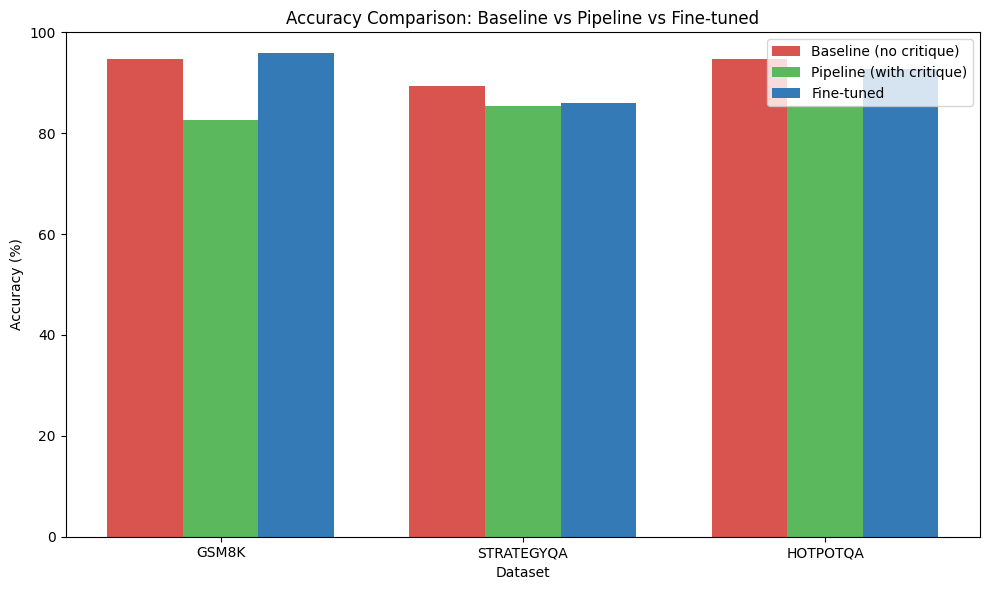

Plot saved to /content/drive/MyDrive/llm_project/accuracy_comparison.png


In [48]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['gsm8k', 'strategyqa', 'hotpotqa']

b_accs, p_accs, f_accs = [], [], []
for d in datasets:
    b_accs.append(baseline_df[baseline_df['dataset']==d]['is_correct'].mean()*100)
    p_accs.append(pipeline_df[pipeline_df['dataset']==d]['is_correct'].mean()*100)
    ft = finetuned_df[finetuned_df['dataset']==d] if len(finetuned_df) > 0 else pd.DataFrame()
    f_accs.append(ft['is_correct'].mean()*100 if len(ft) > 0 else 0)

x = np.arange(len(datasets))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, b_accs, width, label='Baseline (no critique)', color='#d9534f')
ax.bar(x,         p_accs, width, label='Pipeline (with critique)', color='#5cb85c')
ax.bar(x + width, f_accs, width, label='Fine-tuned', color='#337ab7')

ax.set_xlabel('Dataset')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy Comparison: Baseline vs Pipeline vs Fine-tuned')
ax.set_xticks(x)
ax.set_xticklabels([d.upper() for d in datasets])
ax.legend()
ax.set_ylim(0, 100)

# The problematic loop block has been removed as it was causing a TypeError and was not contributing to the plot.

plt.tight_layout()
PLOT_PATH = '/content/drive/MyDrive/llm_project/accuracy_comparison.png'
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f'Plot saved to {PLOT_PATH}')

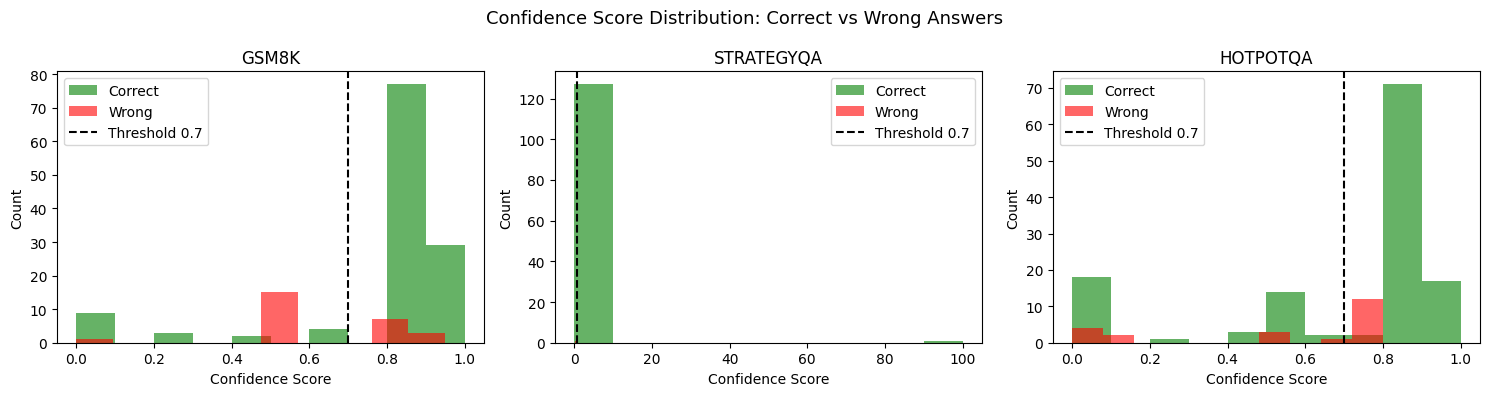

Confidence plot saved to /content/drive/MyDrive/llm_project/confidence_distribution.png


In [49]:
# Confidence score distribution plot — shows critic is meaningful
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, dataset in enumerate(datasets):
    p = pipeline_df[pipeline_df['dataset'] == dataset].copy()
    p['conf'] = p['critique'].apply(safe_get_confidence)

    correct_conf = p[p['is_correct'] == True]['conf']
    wrong_conf   = p[p['is_correct'] == False]['conf']

    axes[i].hist(correct_conf, bins=10, alpha=0.6, color='green', label='Correct')
    axes[i].hist(wrong_conf,   bins=10, alpha=0.6, color='red',   label='Wrong')
    axes[i].axvline(x=0.7, color='black', linestyle='--', label='Threshold 0.7')
    axes[i].set_title(dataset.upper())
    axes[i].set_xlabel('Confidence Score')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Confidence Score Distribution: Correct vs Wrong Answers', fontsize=13)
plt.tight_layout()
CONF_PLOT_PATH = '/content/drive/MyDrive/llm_project/confidence_distribution.png'
plt.savefig(CONF_PLOT_PATH, dpi=150)
plt.show()
print(f'Confidence plot saved to {CONF_PLOT_PATH}')